In [1]:
# Mounting google drive and essentials
# import sys
# from google.colab import drive
# drive.mount('/content/drive')
# sys.path.append("./drive/MyDrive/virtual_bag/self_dev_tools/")

In [1]:
import numpy as np
import math
import pandas as pd
from matplotlib import pyplot as plt
import seaborn as sns
import warnings
import itertools
from collections import defaultdict
# For google drive
# import module1sdt as m1sdt
# import module2sdt as m2sdt
# import module3sdt as m3sdt
# For Home
from self_dev_tools import module1sdt as m1sdt
from self_dev_tools import module2sdt as m2sdt
from self_dev_tools  import module3sdt as m3sdt
from self_dev_tools import module4sdt as m4sdt

In [2]:
import numpy as np

# Generate a probability matrix for 1 neighbor
prob_matrix, neighborhood_states = m4sdt.generate_neighborhood_probabilities(ne_num=1)

# Add noise to the probability matrix (e.g., 10% noise)
noisy_prob_matrix = m4sdt.add_noise_to_prob_matrix(prob_matrix, prob=0.1)

# Generate data with 1 neighbor (column 1) and an extra random column (column 2)
samp_size = 200
input_array = m4sdt.generate_data_from_neighborhoods(ne_num=1, samp_size=samp_size, prob_matrix=noisy_prob_matrix, neighborhood_states=neighborhood_states)

# Add an extra random column (column 2) to simulate irrelevant variables
extra_column = np.random.randint(0, 2, samp_size)
input_array = np.column_stack([input_array, extra_column])

# Simple test: verification
# For [] (empty neighborhood)
associate_summary = m2sdt.associate_cdate(input_array, 0, [])
associate_summary = m2sdt.calculate_likelihood(associate_summary)
print(f"The likelihood for {associate_summary['cdate']} is {associate_summary['ll_hood']}")

# For [1] (only the true neighbor)
associate_summary = m2sdt.associate_cdate(input_array, 0, [1])
associate_summary = m2sdt.calculate_likelihood(associate_summary)
print(f"The likelihood for {associate_summary['cdate']} is {associate_summary['ll_hood']}")

# For [2] (irrelevant column)
associate_summary = m2sdt.associate_cdate(input_array, 0, [2])
associate_summary = m2sdt.calculate_likelihood(associate_summary)
print(f"The likelihood for {associate_summary['cdate']} is {associate_summary['ll_hood']}")

# For [1, 2] (true neighbor + irrelevant column)
associate_summary = m2sdt.associate_cdate(input_array, 0, [1, 2])
associate_summary = m2sdt.calculate_likelihood(associate_summary)
print(f"The likelihood for {associate_summary['cdate']} is {associate_summary['ll_hood']}")


The likelihood for [] is 4.446524878023502e-60
The likelihood for [1] is 4.7591880435423605e-60
The likelihood for [2] is 4.5041652238988695e-60
The likelihood for [1, 2] is 5.015760176032057e-60


In [4]:
# simple test: data generation

test_array= np.random.randint(low=0, high=2, size=(200, 10))
test_array[:,1] = m3sdt.flip_with_probability(test_array[:,0],0.1)
test_array[:,2] = m3sdt.flip_with_probability(test_array[:,0],0.2)

# For calculating the likelihood associated to a given node and a candidate neighborhood
associate_summary = m2sdt.associate_cdate(test_array, 0, [2])
associate_summary = m2sdt.calculate_likelihood(associate_summary)
associate_summary

{'node': 0,
 'cdate': [2],
 'cdnhood_configs': array([[0],
        [1]]),
 'cdnhood_count': array([ 96., 104.]),
 'joint_configs': array([[0, 0],
        [0, 1],
        [1, 0],
        [1, 1]]),
 'joint_count': array([71., 22., 25., 82.]),
 'cdconfig_map': array([0., 1., 0., 1.]),
 'probabilities': array([0.73958333, 0.21153846, 0.26041667, 0.78846154]),
 'll_hood': np.float64(6.086563965931741e-48)}

In [5]:
# To get all neighborhood candidates of a given size of a specific node
m2sdt.get_candidates({0}, {0, 1, 2, 3, 4, 5, 6}, 4)

array([[1, 2, 3, 4],
       [1, 2, 3, 5],
       [1, 2, 3, 6],
       [1, 2, 4, 5],
       [1, 2, 4, 6],
       [1, 2, 5, 6],
       [1, 3, 4, 5],
       [1, 3, 4, 6],
       [1, 3, 5, 6],
       [1, 4, 5, 6],
       [2, 3, 4, 5],
       [2, 3, 4, 6],
       [2, 3, 5, 6],
       [2, 4, 5, 6],
       [3, 4, 5, 6]])

## Verifying the distribution of the likelihoods for i.i.d data

Here we are going to verify the distribution of the likelihoods for a range of candidate sizes when data is completely random.

Here we see the the penalized likelihood.

/tmp/ipykernel_6836/740464550.py:33: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(x='Neighborhood Size', y='Log-Likelihood', data=df, palette='muted', cut=0)


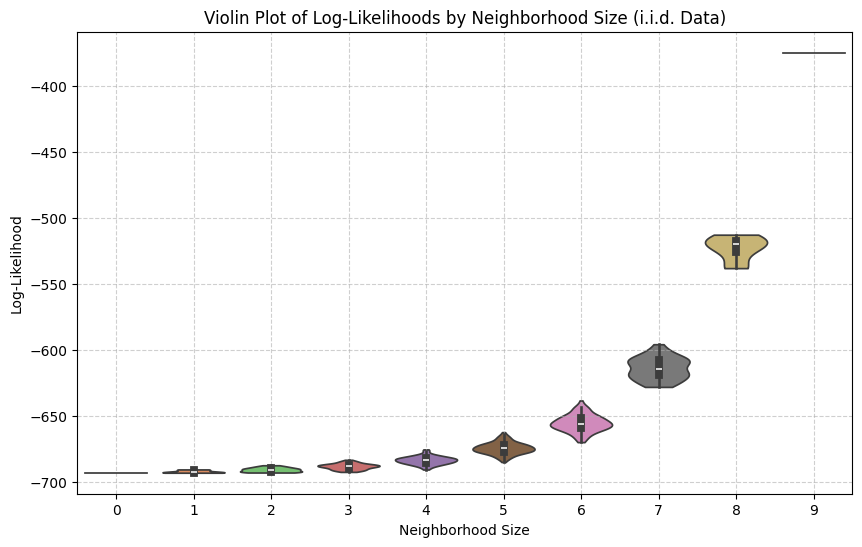

In [6]:
# Generate i.i.d. uniform binary data
np.random.seed(42)  # For reproducibility
test_array = np.random.randint(low=0, high=2, size=(1000, 10))

# Get all candidate neighborhoods for node 0
candidates = m2sdt.get_cand_tillsize(0, set(range(test_array.shape[1])), pow(10,6))
candidates.insert(0, [])  # Include the empty neighborhood

# Store likelihoods by neighborhood size
dist_repo = {i: [] for i in range(test_array.shape[1])}
for cand in candidates:
    cand_adjust = cand.tolist() if len(cand) > 0 else []
    associate_summary = m2sdt.associate_cdate(test_array, 0, cand_adjust)
    associate_summary = m2sdt.calculate_likelihood(associate_summary)
    associate_summary = m2sdt.penalize_llhood(associate_summary, 0.5, 1000)
    dist_repo[len(cand)].append(associate_summary['ll_hood'])

# Prepare data for violin plots
violin_data = []
sizes = []
for size in dist_repo.keys():
    if dist_repo[size]:
        log_likelihoods = [np.log(x) for x in dist_repo[size] if x > 0]
        violin_data.extend(log_likelihoods)
        sizes.extend([size] * len(log_likelihoods))

# Create a DataFrame for seaborn
import pandas as pd
df = pd.DataFrame({'Log-Likelihood': violin_data, 'Neighborhood Size': sizes})

# Plot violin plots
plt.figure(figsize=(10, 6))
sns.violinplot(x='Neighborhood Size', y='Log-Likelihood', data=df, palette='muted', cut=0)
plt.title('Violin Plot of Log-Likelihoods by Neighborhood Size (i.i.d. Data)')
plt.xlabel('Neighborhood Size')
plt.ylabel('Log-Likelihood')
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()


/tmp/ipykernel_6836/2320355392.py:33: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(x='Neighborhood Size', y='Log-penLikelihood', data=df, palette='muted', cut=0)


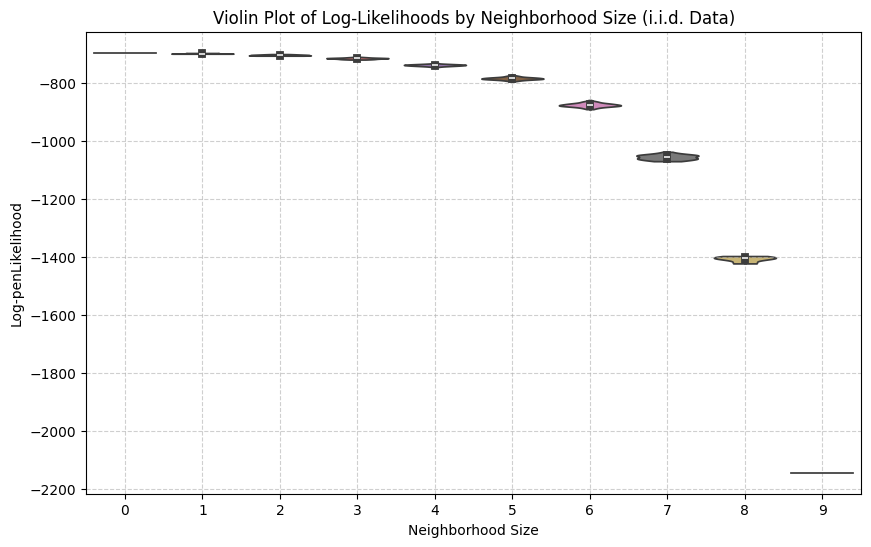

In [7]:
# Generate i.i.d. uniform binary data
np.random.seed(42)  # For reproducibility
test_array = np.random.randint(low=0, high=2, size=(1000, 10))

# Get all candidate neighborhoods for node 0
candidates = m2sdt.get_cand_tillsize(0, set(range(test_array.shape[1])), pow(10,6) )
candidates.insert(0, [])  # Include the empty neighborhood

# Store likelihoods by neighborhood size
dist_repo = {i: [] for i in range(test_array.shape[1])}
for cand in candidates:
    cand_adjust = cand.tolist() if len(cand) > 0 else []
    associate_summary = m2sdt.associate_cdate(test_array, 0, cand_adjust)
    associate_summary = m2sdt.calculate_likelihood(associate_summary)
    associate_summary = m2sdt.penalize_llhood(associate_summary, 0.5, 1000)
    dist_repo[len(cand)].append(associate_summary['pen_llhood'])

# Prepare data for violin plots
violin_data = []
sizes = []
for size in dist_repo.keys():
    if dist_repo[size]:
        log_penlikelihoods = [x for x in dist_repo[size]]
        violin_data.extend(log_penlikelihoods)
        sizes.extend([size] * len(log_penlikelihoods))

# Create a DataFrame for seaborn
import pandas as pd
df = pd.DataFrame({'Log-penLikelihood': violin_data, 'Neighborhood Size': sizes})

# Plot violin plots
plt.figure(figsize=(10, 6))
sns.violinplot(x='Neighborhood Size', y='Log-penLikelihood', data=df, palette='muted', cut=0)
plt.title('Violin Plot of Log-Likelihoods by Neighborhood Size (i.i.d. Data)')
plt.xlabel('Neighborhood Size')
plt.ylabel('Log-penLikelihood')
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()

/tmp/ipykernel_6836/1365980462.py:52: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout(rect=[0, 0.1, 1, 0.95])


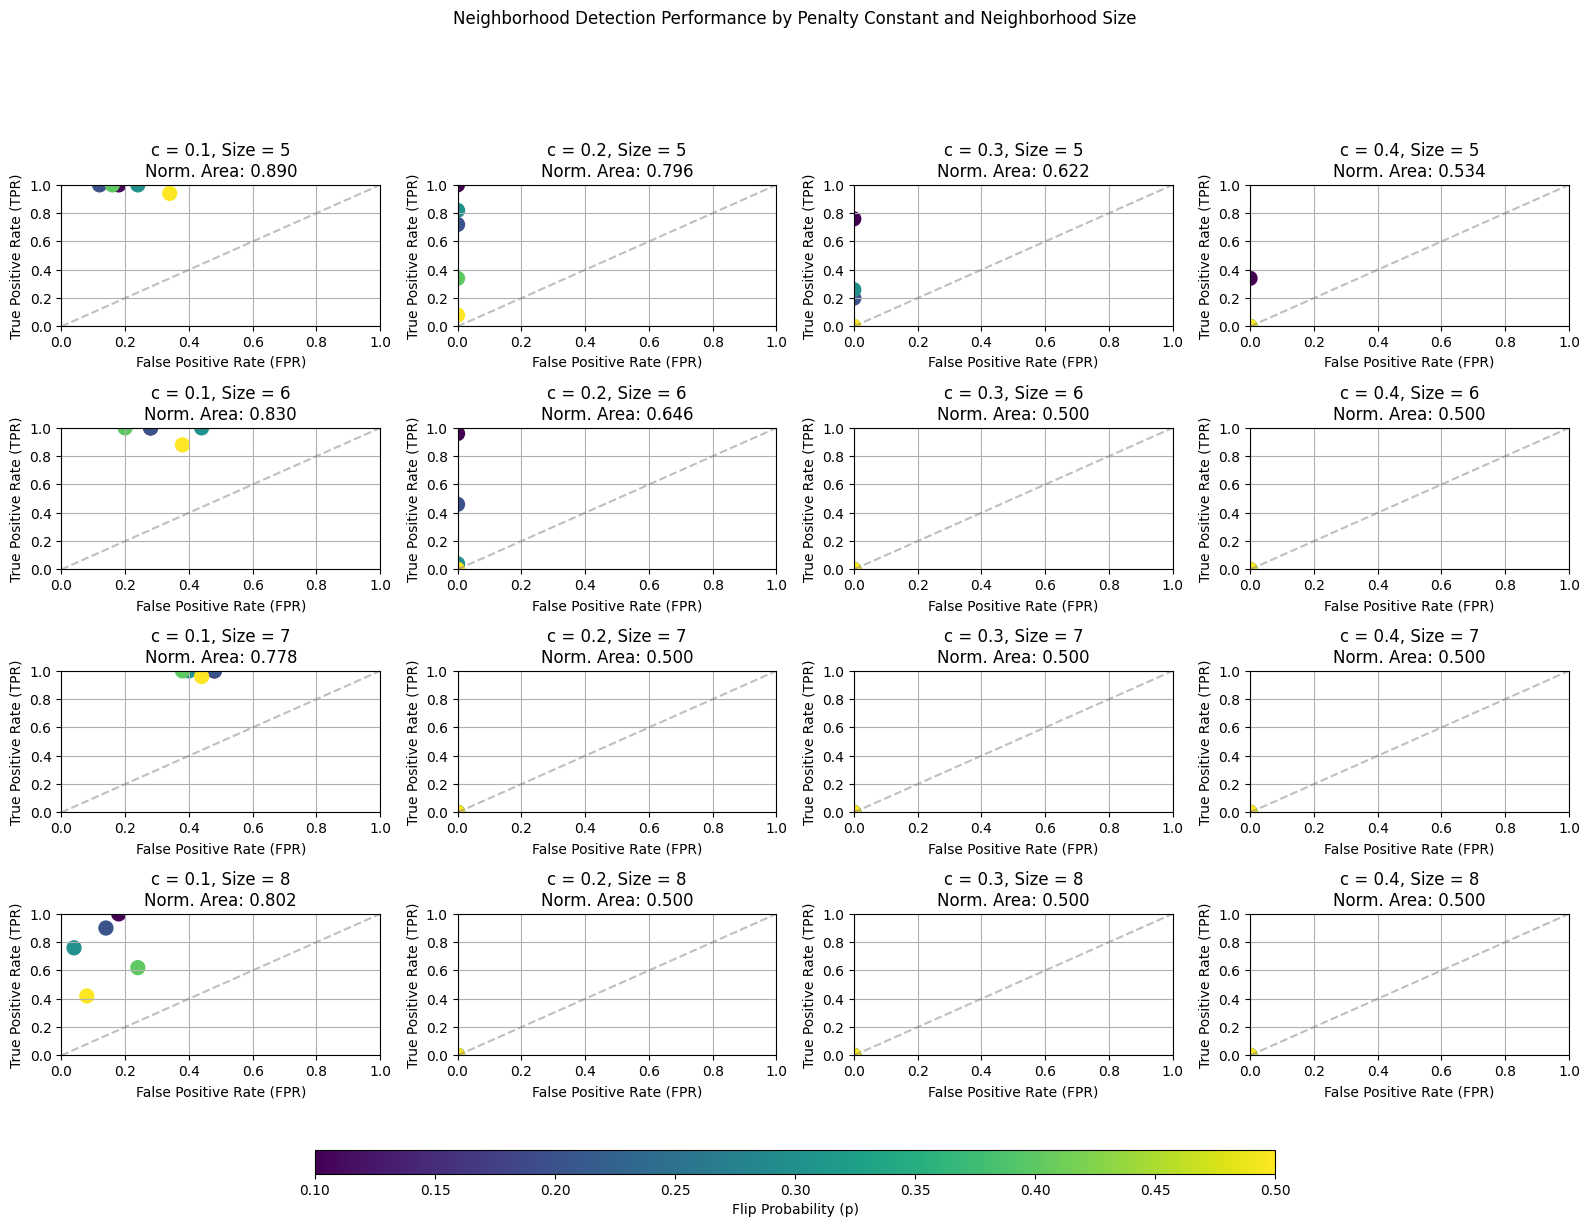

In [8]:
# ROC curves for the method

# Parameters
prob_array = np.linspace(0.1, 0.5, 5)
c_cte_values = [0.1, 0.2, 0.3, 0.4]
ne_num_values = [5, 6, 7, 8]  # Neighborhood sizes

# Create figure and subplots
fig, axes = plt.subplots(len(ne_num_values), len(c_cte_values), figsize=(16, 12))
fig.suptitle('Neighborhood Detection Performance by Penalty Constant and Neighborhood Size', y=1.02)

# Create a separate axis for the colorbar at the bottom
cbar_ax = fig.add_axes([0.2, 0.05, 0.6, 0.02])

# Plot data and collect scatter objects for colorbar
scatter_objects = []
for row, ne_num in enumerate(ne_num_values):
    for col, c_cte in enumerate(c_cte_values):
        fpr_x = np.zeros(prob_array.shape[0])
        tpr_y = np.zeros(prob_array.shape[0])
        total_area = 0  # Initialize total area for this subplot

        for i, prob in enumerate(prob_array):
            SNR, TPR, FPR = m4sdt.test_method(prob, c_cte, ne_num, 100, 500)
            fpr_x[i] = FPR
            tpr_y[i] = TPR

            # Calculate area under the "triangle" for this point
            area = (TPR + (1 - FPR)) / 2  # Use TPR/FPR from test_method, not tpr_y/fpr_x
            total_area += area

        # Normalize total area
        normalized_area = total_area / len(prob_array)

        # Plot scatter
        sc = axes[row, col].scatter(fpr_x, tpr_y, c=prob_array, cmap='viridis', s=100, vmin=0.1, vmax=0.5)
        scatter_objects.append(sc)
        axes[row, col].set_xlim([0, 1])
        axes[row, col].set_ylim([0, 1])
        axes[row, col].set_xlabel('False Positive Rate (FPR)')
        axes[row, col].set_ylabel('True Positive Rate (TPR)')
        axes[row, col].set_title(f'c = {c_cte}, Size = {ne_num}\nNorm. Area: {normalized_area:.3f}')
        axes[row, col].grid(True)

        # Add diagonal line for random guessing
        axes[row, col].plot([0, 1], [0, 1], linestyle='--', color='gray', alpha=0.5)

# Create colorbar using the last scatter object
cbar = fig.colorbar(scatter_objects[-1], cax=cbar_ax, orientation='horizontal')
cbar.set_label('Flip Probability (p)')

plt.tight_layout(rect=[0, 0.1, 1, 0.95])
plt.show()


In [ ]:
# Parameters
prob_array = np.linspace(0.1, 0.5, 5)
c_cte_values = [0.1, 0.2, 0.3, 0.4]
ne_num_values = list(range(1, 11))  # Neighborhood sizes from 1 to 10

# Create DataFrame with an extra row for sums
results_df = pd.DataFrame(index=list(ne_num_values) + ['Sum'],
                          columns=[f'c={c}' for c in c_cte_values])

# Calculate normalized areas
for ne_num in ne_num_values:
    for c_cte in c_cte_values:
        total_area = 0
        for prob in prob_array:
            SNR, TPR, FPR = m4sdt.test_method(prob, c_cte, ne_num, 100, 500)
            # Calculate area for this point
            area = (TPR + (1 - FPR)) / 2
            total_area += area

        # Normalize by number of probability values
        normalized_area = total_area / len(prob_array)
        results_df.at[ne_num, f'c={c_cte}'] = normalized_area

# Calculate sums for each penalty constant
for c_cte in c_cte_values:
    results_df.at['Sum', f'c={c_cte}'] = results_df[f'c={c_cte}'].sum()

# Round to 3 decimal places for readability
results_df = results_df.round(3)

# Display the table
print("Normalized Performance Metric (Area under curve / number of probabilities):")
display(results_df)
